# 04. Drzewo regresyjne: przewidywanie wyniku egzaminu

Cel: pokazać, że drzewo może przewidywać nie tylko klasy, ale też liczbę.

W drzewie regresyjnym liść zwraca zwykle średnią wartość `y` dla przykładów, które trafiły do tego liścia.

## Co zmienia się względem klasyfikacji?

Do tej pory przewidywaliśmy klasę, np.:

```text
kup_lody = tak / nie
zaliczenie = zaliczone / do_poprawy
```

Teraz **przewidujemy liczbę**:

```text
wynik egzaminu w procentach
```

To znaczy, że nie liczymy już Gini impurity, bo Gini dotyczy mieszania klas.

W regresji drzewo szuka takich podziałów, które tworzą grupy o możliwie podobnych wartościach liczbowych.  
Intuicyjnie: dobry split zmniejsza rozrzut wyników w liściach.

W klasyfikacji używaliśmy **Gini impurity**, bo przewidywaliśmy **klasy**. W **regresji** przewidujemy **liczbę**, więc **drzewo szuka podziałów**, które **zmniejszają rozrzut wartości liczbowych w liściach** — **najczęściej** przez **błąd kwadratowy** (`squared_error`). Intuicja jest podobna: dobry split tworzy grupy, w których wartości `y` są do siebie bardziej podobne.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE = Path.cwd()
for candidate in [BASE, BASE.parent, Path("/mnt/data/drzewa_decyzyjne_dydaktyka")]:
    if (candidate / "data" / "03_wynik_egzaminu.csv").exists():
        BASE = candidate
        break
else:
    BASE = Path.cwd()

csv_path = BASE / "data" / "03_wynik_egzaminu.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    # Fallback dydaktyczny: fikcyjne dane o nauce i wyniku egzaminu.
    rng = np.random.default_rng(42)
    n = 130
    godziny_nauki = np.round(rng.uniform(0, 12, n), 1)
    powtorki = rng.integers(0, 8, n)
    sen_h = np.round(np.clip(rng.normal(7.0, 1.2, n), 3.5, 10), 1)
    stres_1_10 = rng.integers(1, 11, n)

    wynik_pct = (
        24
        + 5.8 * godziny_nauki
        + 2.7 * powtorki
        + 1.9 * sen_h
        - 3.1 * stres_1_10
        - 0.22 * np.maximum(godziny_nauki - 8, 0) ** 2
        + rng.normal(0, 7, n)
    )
    wynik_pct = np.clip(wynik_pct, 0, 100).round(1)

    df = pd.DataFrame({
        "student_id": range(1, n + 1),
        "godziny_nauki": godziny_nauki,
        "powtorki": powtorki,
        "sen_h": sen_h,
        "stres_1_10": stres_1_10,
        "wynik_pct": wynik_pct,
    })

df.head()


,student_id,godziny_nauki,powtorki,sen_h,stres_1_10,wynik_pct
0,1,9.3,6,6.5,10,78.2
1,2,5.3,1,8.8,7,56.1
2,3,10.3,2,5.7,7,79.0
3,4,8.4,7,5.9,1,89.8
4,5,1.1,7,7.8,7,26.2


# 1. Dane i intuicja

Zakładamy, że wynik egzaminu zależy między innymi od liczby godzin nauki, liczby powtórek, snu i stresu. Relacja nie musi być liniowa: po pewnym czasie kolejne godziny nauki mogą dawać mniejszy przyrost.

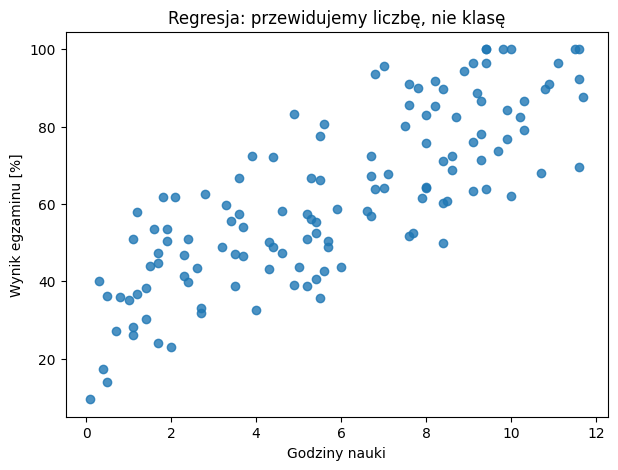

In [2]:
plt.figure(figsize=(7, 5))
plt.scatter(df["godziny_nauki"], df["wynik_pct"], alpha=0.8)
plt.xlabel("Godziny nauki")
plt.ylabel("Wynik egzaminu [%]")
plt.title("Regresja: przewidujemy liczbę, nie klasę")
plt.show()

# 2. Jednowymiarowe drzewo: schodki

Dla jednej cechy drzewo regresyjne daje funkcję schodkową. W każdym przedziale przewidywana jest średnia z przykładów w liściu.

### Dlaczego drzewo regresyjne daje „schodki”?

Model liniowy próbuje narysować jedną gładką linię.

Drzewo regresyjne działa inaczej:

```text
1. dzieli zakres cechy na przedziały,
2. w każdym przedziale tworzy liść,
3. w liściu zwraca średnią wartość targetu.
```

Dlatego predykcja drzewa regresyjnego jest funkcją schodkową.  
W obrębie jednego liścia wszystkie obserwacje dostają tę samą wartość predykcji.

## Czego tak naprawdę szuka drzewo regresyjne?

Drzewo regresyjne nie próbuje dopasować jednej globalnej prostej.

Zamiast tego:

1. **dzieli** przestrzeń cechy **na przedziały**,
2. w **każdym przedziale** szuka **średniej** wartości `y`,
3. **wybiera** takie **podziały**, aby **wartości** w przedziale były możliwie **podobne do siebie**.

Można o tym myśleć jak o:

```text
lokalnym uśrednianiu danych
```

Im głębsze drzewo:

- tym więcej przedziałów,
- tym bardziej szczegółowe lokalne średnie,
- tym dokładniejsze dopasowanie do danych treningowych.

Dlatego drzewo regresyjne tworzy funkcję schodkową:
każdy „schodek” to średnia przewidywana w danym liściu.

W pewnym sensie drzewo regresyjne tworzy:

```text
nieliniowe dopasowanie kawałkami
```

zamiast jednej globalnej funkcji.

**regresja liniowa**:
jedna funkcja dla całej przestrzeni

**drzewo**:
inna lokalna średnia w różnych regionach przestrzeni

Można myśleć o **drzewie regresyjnym** jako o:

```text
lokalnym dopasowaniu kawałkami
```

W **każdym przedziale drzewo** przewiduje **jedną stałą wartość**
(średnią z danych w liściu).

Dlatego:

- **wewnątrz przedziału** **predykcja** jest **pozioma**,
- **między przedziałami** pojawiają się **pionowe skoki**.

**Regresja liniowa**róbuje dopasować **jedną globalną prostą**:

$$
y = ax + b
$$

Natomiast **drzewo regresyjne** tworzy **wiele lokalnych średnich**:

```text
stała wartość w regionie 1
stała wartość w regionie 2
stała wartość w regionie 3
...
```

Dlatego drzewo może aproksymować zależności nieliniowe,
ale robi to schodkami.

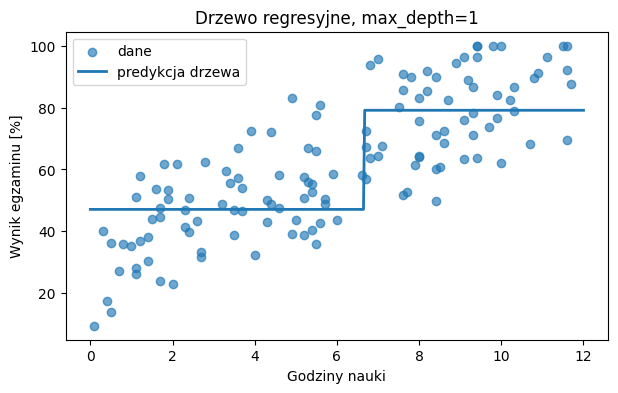

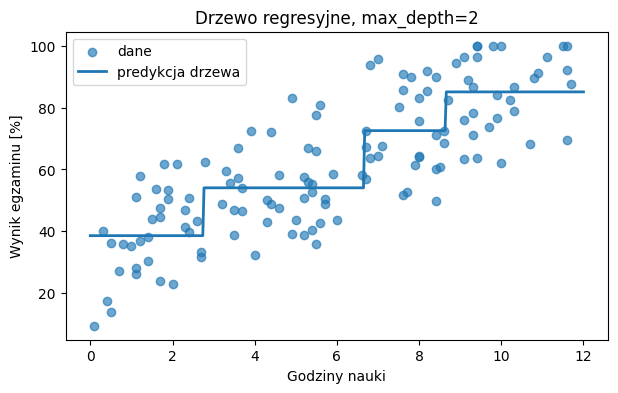

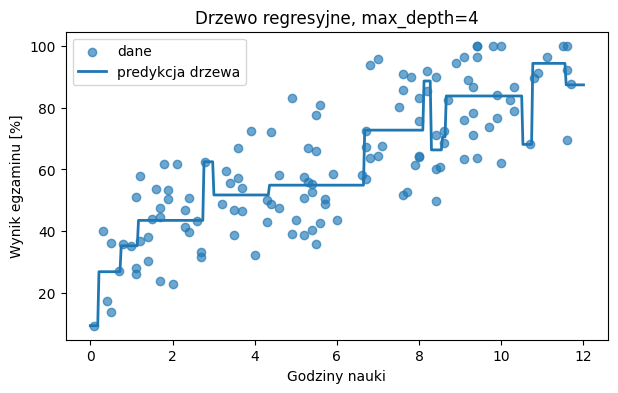

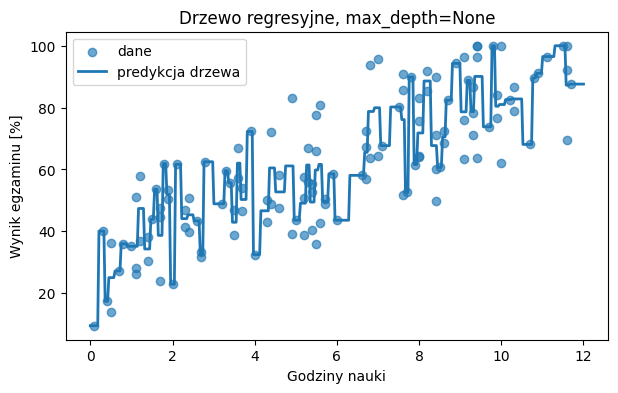

In [3]:
X_one = df[["godziny_nauki"]]
y = df["wynik_pct"]

x_grid = pd.DataFrame({"godziny_nauki": np.linspace(0, 12, 400)})

for depth in [1, 2, 4, None]:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(X_one, y)
    pred = reg.predict(x_grid)

    plt.figure(figsize=(7, 4))
    plt.scatter(df["godziny_nauki"], y, alpha=0.65, label="dane")
    plt.plot(x_grid["godziny_nauki"], pred, linewidth=2, label="predykcja drzewa")
    plt.xlabel("Godziny nauki")
    plt.ylabel("Wynik egzaminu [%]")
    plt.title(f"Drzewo regresyjne, max_depth={depth}")
    plt.legend()
    plt.show()

# 3. Jak drzewo regresyjne wybiera próg?

W klasyfikacji wybieraliśmy próg, który minimalizował nieczystość Gini.

W regresji nie mamy klas, tylko wartości liczbowe, np. wynik egzaminu w procentach.
Dlatego drzewo szuka takiego progu, żeby wartości w liściach były możliwie podobne do siebie.

Najprostsza intuicja:

- po lewej stronie progu trafiają osoby z mniejszą liczbą godzin nauki,
- po prawej stronie osoby z większą liczbą godzin nauki,
- w każdym liściu model przewiduje średnią wartość `wynik_pct`.

Dobry próg to taki, który zmniejsza błąd kwadratowy, czyli MSE.

$$
MSE =
\frac{1}{n}
\sum_i
(y_i - \bar{y})^2
$$

Dla każdego progu liczymy:

$$
MSE_{split}
=
\frac{n_L}{n} MSE_L
+
\frac{n_R}{n} MSE_R
$$

Drzewo wybiera próg z najmniejszym `MSE_split`.

In [2]:
def mse(values):
    mean = values.mean()
    return np.mean((values - mean) ** 2)


def threshold_table_regression(data, feature, target="wynik_pct"):
    values = np.sort(data[feature].unique())
    thresholds = (values[:-1] + values[1:]) / 2

    rows = []
    parent = mse(data[target])

    for t in thresholds:
        left = data[data[feature] <= t]
        right = data[data[feature] > t]

        if len(left) == 0 or len(right) == 0:
            continue

        weighted = (
            len(left) / len(data) * mse(left[target])
            +
            len(right) / len(data) * mse(right[target])
        )

        rows.append({
            "cecha": feature,
            "prog": round(t, 2),
            "mse_po_podziale": weighted,
            "zysk_mse": parent - weighted,
            "lewa_liczba": len(left),
            "prawa_liczba": len(right),
            "srednia_lewa": left[target].mean(),
            "srednia_prawa": right[target].mean()
        })

    return pd.DataFrame(rows).sort_values("mse_po_podziale")


threshold_table_regression(df, "godziny_nauki").head(10)

,cecha,prog,mse_po_podziale,zysk_mse,lewa_liczba,prawa_liczba,srednia_lewa,srednia_prawa
43,godziny_nauki,6.65,211.656170,254.334368,71,59,47.101408,79.133898
42,godziny_nauki,6.30,214.058893,251.931645,70,60,46.944286,78.783333
44,godziny_nauki,6.75,214.681047,251.309491,74,56,47.848649,79.862500
41,godziny_nauki,5.95,223.337567,242.652971,69,61,46.992754,78.206557
40,godziny_nauki,5.80,225.195316,240.795222,68,62,46.822059,77.890323
45,godziny_nauki,6.90,228.965374,237.025164,76,54,48.661842,79.903704
38,godziny_nauki,5.55,236.991146,228.999392,64,66,46.271875,76.540909
39,godziny_nauki,5.65,237.001175,228.989362,66,64,46.737879,77.006250
37,godziny_nauki,5.45,238.699954,227.290584,61,69,45.604918,75.814493
46,godziny_nauki,7.05,243.639918,222.350620,78,52,49.464103,79.901923


```
prog = 6.65
mse_po_podziale = 211.656
zysk_mse = 254.334
lewa_liczba = 71
prawa_liczba = 59
srednia_lewa = 47.10
srednia_prawa = 79.13
```

## Ręczne przeliczenie jednego progu

Weźmy najlepszy próg:

```text
godziny_nauki <= 6.65
```

Po podziale mamy:

```text
lewa_liczba  = 71
prawa_liczba = 59
```

W drzewie regresyjnym w każdym liściu przewidujemy średnią wartość `y`.

Dla lewej gałęzi:

```text
średni wynik = 47.10
MSE_L = 218.85
```

Dla prawej gałęzi:

```text
średni wynik = 79.13
MSE_R = 203.00
```

Teraz liczymy średnią ważoną:

$$
MSE_{split}
=
\frac{71}{130} \cdot 218.85
+
\frac{59}{130} \cdot 203.00
$$

$$
MSE_{split}
\approx 211.66
$$

To jest wartość widoczna w tabeli jako `mse_po_podziale`.

Im mniejsze `mse_po_podziale`, tym lepszy próg.

### To jest mały przykład rachunkowy pokazujący mechanikę. Pełne MSE dla gałęzi liczymy niżej z rzeczywistych obserwacji w DataFrame:

### Jak dokładnie liczymy MSE?

W lewej gałęzi model przewiduje średnią wartość:

$$
\bar{y}_L = 47.10
$$

Załóżmy, że kilka pierwszych wyników wygląda tak:

```text
38, 41, 45, 50, 53
```

Liczymy odchylenia od średniej:

$$
38 - 47.10 = -9.10
$$

$$
41 - 47.10 = -6.10
$$

$$
45 - 47.10 = -2.10
$$

$$
50 - 47.10 = 2.90
$$

$$
53 - 47.10 = 5.90
$$

Podnosimy do kwadratu:

$$
(-9.10)^2 = 82.81
$$

$$
(-6.10)^2 = 37.21
$$

$$
(-2.10)^2 = 4.41
$$

$$
(2.90)^2 = 8.41
$$

$$
(5.90)^2 = 34.81
$$

Im większe odchylenie od średniej,
tym większa kara w MSE.

Na końcu średnia z takich kwadratów daje:

$$
MSE_L \approx 218.85
$$

Analogicznie liczymy:

$$
MSE_R \approx 203.00
$$

Drzewo wybiera taki próg,
dla którego średnia ważona błędów po podziale jest najmniejsza.

In [10]:
t = 6.65

left = df[df["godziny_nauki"] <= t].copy()
right = df[df["godziny_nauki"] > t].copy()

mean_left = left["wynik_pct"].mean()
mean_right = right["wynik_pct"].mean()

left_calc = left[["godziny_nauki", "wynik_pct"]].copy()
left_calc["srednia_liscia"] = mean_left
left_calc["blad"] = left_calc["wynik_pct"] - left_calc["srednia_liscia"]
left_calc["blad_kwadrat"] = left_calc["blad"] ** 2

left_calc.head(10)

,godziny_nauki,wynik_pct,srednia_liscia,blad,blad_kwadrat
1,5.3,56.1,47.101408,8.998592,80.974650
4,1.1,26.2,47.101408,-20.901408,436.868875
8,1.5,43.9,47.101408,-3.201408,10.249016
9,5.4,52.6,47.101408,5.498592,30.234509
10,4.4,48.9,47.101408,1.798592,3.234932
14,5.3,66.8,47.101408,19.698592,388.034509
15,2.7,31.7,47.101408,-15.401408,237.203382
17,0.8,36.0,47.101408,-11.101408,123.241270
21,4.3,50.2,47.101408,3.098592,9.601270
25,2.3,46.9,47.101408,-0.201408,0.040565


In [11]:
print("Średnia LEFT:", round(mean_left, 2))
print("MSE LEFT:", round(left_calc["blad_kwadrat"].mean(), 2))

Średnia LEFT: 47.1
MSE LEFT: 218.85


In [14]:
right_calc = right[["godziny_nauki", "wynik_pct"]].copy()
right_calc["srednia_liscia"] = mean_right
right_calc["blad"] = right_calc["wynik_pct"] - right_calc["srednia_liscia"]
right_calc["blad_kwadrat"] = right_calc["blad"] ** 2

print(right_calc.head(10))

    godziny_nauki  wynik_pct  srednia_liscia       blad  blad_kwadrat
0             9.3       78.2       79.133898  -0.933898      0.872166
2            10.3       79.0       79.133898  -0.133898      0.017929
3             8.4       89.8       79.133898  10.666102    113.765725
5            11.7       87.6       79.133898   8.466102     71.674878
6             9.1       76.0       79.133898  -3.133898      9.821319
7             9.4       96.5       79.133898  17.366102    301.581488
11           11.1       96.5       79.133898  17.366102    301.581488
12            7.7       52.6       79.133898 -26.533898    704.047759
13            9.9       76.7       79.133898  -2.433898      5.923861
16            6.7       72.4       79.133898  -6.733898     45.345386


In [15]:
print("Średnia RIGHT:", round(mean_right, 2))
print("MSE RIGHT:", round(right_calc["blad_kwadrat"].mean(), 2))

Średnia RIGHT: 79.13
MSE RIGHT: 203.0


In [5]:
t = 6.65

left = df[df["godziny_nauki"] <= t]
right = df[df["godziny_nauki"] > t]

print("Lewa liczba:", len(left))
print("Prawa liczba:", len(right))

print("\nŚrednia LEFT:", round(left["wynik_pct"].mean(), 2))
print("Średnia RIGHT:", round(right["wynik_pct"].mean(), 2))

mse_left = mse(left["wynik_pct"])
mse_right = mse(right["wynik_pct"])

weighted = (
    len(left) / len(df) * mse_left
    +
    len(right) / len(df) * mse_right
)

print("\nMSE LEFT:", round(mse_left, 2))
print("MSE RIGHT:", round(mse_right, 2))
print("MSE split:", round(weighted, 2))

Lewa liczba: 71
Prawa liczba: 59

Średnia LEFT: 47.1
Średnia RIGHT: 79.13

MSE LEFT: 218.85
MSE RIGHT: 203.0
MSE split: 211.66


Widzimy więc bardzo podobny mechanizm jak w klasyfikacji.

W klasyfikacji:

`dobry split = czyste klasy po podziale`

W regresji:

`dobry split = mały rozrzut wartości liczbowych po podziale`

Dlatego drzewo regresyjne także testuje wiele progów,
ale zamiast Gini minimalizuje błąd, np. MSE.

klasyfikacja:
Gini = rozrzut klas

regresja:
MSE = rozrzut wartości liczbowych

# 4. Co jest w liściach?

Zobaczmy małe drzewo i jego reguły.

### Co oznacza wartość w liściu?

W klasyfikacji liść zwracał klasę dominującą.

W regresji liść zwraca wartość liczbową — najczęściej średnią z `y` dla obserwacji, które trafiły do tego liścia.

Przykład:

```text
liść zawiera wyniki: 62, 66, 70
predykcja liścia = średnia = 66
```

Dlatego **drzewo regresyjne** można czytać jako **zestaw reguł prowadzących do średnich wartości**.

|--- godziny_nauki <= 6.65
|   |--- godziny_nauki <= 2.75
|   |   |--- value: [38.61]
|   |--- godziny_nauki >  2.75
|   |   |--- value: [54.07]
|--- godziny_nauki >  6.65
|   |--- godziny_nauki <= 8.65
|   |   |--- value: [72.55]
|   |--- godziny_nauki >  8.65
|   |   |--- value: [85.08]



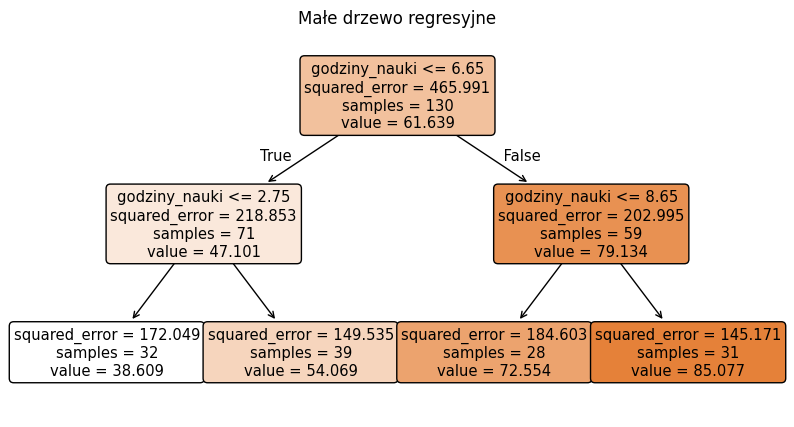

In [4]:
small_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
small_reg.fit(X_one, y)

print(export_text(small_reg, feature_names=["godziny_nauki"]))

plt.figure(figsize=(10, 5))
plot_tree(
    small_reg,
    feature_names=["godziny_nauki"],
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Małe drzewo regresyjne")
plt.show()

## Jak czytać drzewo regresyjne?

Drzewo regresyjne czytamy tak samo jak klasyfikacyjne: od góry do dołu.

Każdy węzeł z warunkiem, np.

```text
godziny_nauki <= 6.65
```

jest pytaniem.

- jeśli warunek jest prawdziwy, idziemy w lewo,
- jeśli warunek jest fałszywy, idziemy w prawo.

Różnica względem klasyfikacji jest w liściach.

W klasyfikacji liść zwraca klasę, np. `zaliczone` albo `do_poprawy`.

W regresji liść zwraca liczbę — najczęściej średnią wartość `y` dla obserwacji, które trafiły do tego liścia.

Przykład:

```text
value = 38.609
```

oznacza, że model przewiduje wynik około `38.6%` dla obserwacji trafiających do tego liścia.

Pole `squared_error` mówi, jak bardzo wartości wyników w danym węźle są rozrzucone wokół średniej.

- mały `squared_error` → wyniki w liściu są podobne,
- duży `squared_error` → wyniki są mocno rozrzucone.

Wartość `value` w liściu to przewidywany wynik. Dla tego typu drzewa jest to średnia wyników w danym liściu.

W tym przykładzie pierwszy podział to:

```text
godziny_nauki <= 6.65
```

W tym uproszczonym przykładzie model ma tylko jedną cechę, więc szuka najlepszego progu właśnie na osi `godziny_nauki`.

Dalej osobno dzieli grupę osób uczących się mniej i osobno grupę osób uczących się więcej.

Każdy końcowy liść zwraca przewidywany wynik egzaminu jako średnią z danych w tym liściu.

## Uwaga dydaktyczna

W tej sekcji model dostaje tylko jedną cechę:

```python
godziny_nauki
```

Dlatego wszystkie splity muszą być wykonywane na tej osi.

Nie oznacza to jeszcze, że `godziny_nauki` są globalnie najlepszą cechą.
Chcemy tutaj jedynie zobaczyć,
jak drzewo regresyjne tworzy schodkową funkcję predykcji w 1D.

# 5. Model z kilkoma cechami

Teraz dodajemy pozostałe cechy i sprawdzamy jakość na zbiorze testowym.

### Jak mierzymy błąd regresji?

W klasyfikacji liczyliśmy np. accuracy.

W regresji predykcja jest liczbą, więc błąd też jest liczbowy.  
W tym notebooku używamy między innymi MAE:

```text
MAE = średnia wartość |prawdziwy wynik - predykcja|
```

Jeżeli MAE wynosi `7`, to oznacza, że model myli się średnio o około 7 punktów procentowych.

In [20]:
X = df[["godziny_nauki", "powtorki", "sen_h", "stres_1_10"]]
y = df["wynik_pct"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

rows = []
for depth in [1, 2, 3, 4, 6, None]:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(X_train, y_train)
    pred_train = reg.predict(X_train)
    pred_test = reg.predict(X_test)
    rows.append({
        "max_depth": "None" if depth is None else depth,
        "liczba_lisci": reg.get_n_leaves(),
        "MAE_train": mean_absolute_error(y_train, pred_train),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "R2_test": r2_score(y_test, pred_test)
    })

pd.DataFrame(rows)

,max_depth,liczba_lisci,MAE_train,MAE_test,R2_test
0,1,2,11.376585,13.275838,0.463701
1,2,4,9.166651,12.055023,0.504440
2,3,8,6.488352,10.662654,0.639327
3,4,16,4.816794,9.899209,0.686985
4,6,48,1.983475,9.360427,0.724205
5,None,88,0.000000,9.271795,0.726080


Niższe MAE oznacza mniejszy przeciętny błąd w punktach procentowych. Bardzo głębokie drzewo może mieć bardzo mały błąd treningowy, bo zapamiętuje pojedyncze obserwacje. Kluczowe jest jednak porównanie z błędem testowym, czyli z zachowaniem na nowych danych.

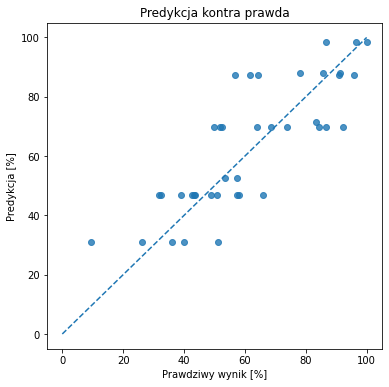

MAE: 10.66
RMSE: 13.27
R2: 0.639


In [21]:
reg = DecisionTreeRegressor(max_depth=3, random_state=42)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.8)
plt.plot([0, 100], [0, 100], linestyle="--")
plt.xlabel("Prawdziwy wynik [%]")
plt.ylabel("Predykcja [%]")
plt.title("Predykcja kontra prawda")
plt.show()

print("MAE:", round(mean_absolute_error(y_test, pred), 2))
print("RMSE:", round(mean_squared_error(y_test, pred) ** 0.5, 2))
print("R2:", round(r2_score(y_test, pred), 3))

`R2` mówi, jaka część zmienności wyniku jest wyjaśniana przez model. Wartości bliżej 1 oznaczają lepsze dopasowanie, ale w praktyce zawsze patrzymy też na MAE/RMSE.

## Jak czytać wykres predykcja kontra prawda?

Ten wykres jest regresyjnym odpowiednikiem pytania:

> jak dobrze model przewiduje na danych testowych?

Na osi X mamy prawdziwy wynik egzaminu.

Na osi Y mamy wynik przewidziany przez model.

Linia przerywana oznacza idealną predykcję:

```text
predykcja = prawdziwa wartość
```

Czyli punkt leżący dokładnie na tej linii oznacza,
że model trafił idealnie.

Jeśli punkt leży:

- blisko linii — predykcja była dobra,
- daleko od linii — model mocno się pomylił,
- powyżej linii — model zawyżył wynik,
- poniżej linii — model zaniżył wynik.

W klasyfikacji analizowaliśmy błędy za pomocą macierzy pomyłek.
W regresji zamiast macierzy pomyłek patrzymy na odległości punktów od linii idealnej oraz liczymy metryki takie jak MAE, RMSE i R2.

Drzewo regresyjne czytamy jak drzewo klasyfikacyjne,
ale liść zwraca liczbę, a nie klasę.

Confusion matrix nie ma tu sensu,
bo nie przewidujemy klas.

Zamiast tego patrzymy na:
- wykres predykcja kontra prawda,
- MAE,
- RMSE,
- R2.

## Czy drzewo zakłada liniową zależność?

Nie.

Regresja liniowa próbuje dopasować jedną globalną prostą:

$$
y = ax + b
$$

Drzewo regresyjne działa inaczej:

- dzieli przestrzeń na regiony,
- w każdym regionie przewiduje lokalną średnią.

Dlatego drzewo może modelować zależności nieliniowe,
ale robi to schodkami zamiast jednej gładkiej funkcji.

---

## Co oznacza linia przerywana na wykresie?

Na wykresie „Predykcja kontra prawda” linia:

```text
predykcja = prawdziwa wartość
```

nie jest modelem.

To tylko linia idealnych trafień.

Punkt leżący dokładnie na tej linii oznacza,
że model przewidział wynik perfekcyjnie.

# 6. Przycinanie drzewa przez `ccp_alpha`

Przycinanie ogranicza złożoność drzewa. Większe `ccp_alpha` zwykle daje mniejsze drzewo.

### Intuicja `ccp_alpha`

`ccp_alpha` to parametr przycinania drzewa.

Można go rozumieć tak:

```text
czy opłaca się zostawić dodatkowy podział,
jeżeli tylko trochę poprawia dopasowanie?
```

Większe `ccp_alpha` karze zbyt rozbudowane drzewa, więc model staje się prostszy.

To jest inny sposób kontrolowania złożoności, obok znanych już parametrów:

```text
max_depth
min_samples_leaf
min_samples_split
```

To jest bardziej zaawansowany parametr, ale idea jest prosta: karzemy drzewo za zbyt wiele podziałów.

## Dlaczego pruning wymaga train/test?

Na danych treningowych bardziej złożone drzewo prawie zawsze daje mniejszy błąd.

Nie oznacza to jednak,
że model będzie lepiej działał na nowych danych.

Dlatego przy pruning porównujemy:

- błąd na train,
- błąd na test.

Jeśli uproszczenie drzewa:
- trochę pogarsza train,
- ale poprawia test,

to znaczy, że model generalizuje lepiej.

In [22]:
base_reg = DecisionTreeRegressor(random_state=42)
path = base_reg.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas

# Pomijamy ostatnią alfę, bo często daje drzewo z jednym liściem.
alphas_to_try = alphas[:-1]

rows = []
for alpha in alphas_to_try:
    reg = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    reg.fit(X_train, y_train)
    rows.append({
        "ccp_alpha": alpha,
        "liczba_lisci": reg.get_n_leaves(),
        "MAE_train": mean_absolute_error(y_train, reg.predict(X_train)),
        "MAE_test": mean_absolute_error(y_test, reg.predict(X_test))
    })

pruning = pd.DataFrame(rows)
pruning.head()

,ccp_alpha,liczba_lisci,MAE_train,MAE_test
0,0.000000e+00,88,0.000000,9.271795
1,1.998889e-14,87,0.000000,9.271795
2,2.197802e-04,86,0.002198,9.269231
3,8.791209e-04,85,0.006593,9.269231
4,8.791209e-04,84,0.010989,9.258974


### Opis kodu -> APPENDIX A.

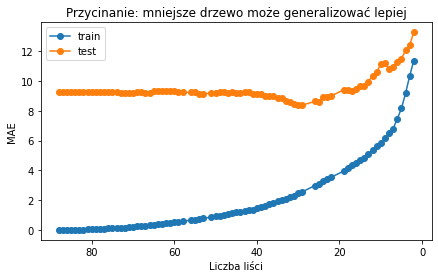

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(pruning["liczba_lisci"], pruning["MAE_train"], marker="o", label="train")
plt.plot(pruning["liczba_lisci"], pruning["MAE_test"], marker="o", label="test")
plt.gca().invert_xaxis()
plt.xlabel("Liczba liści")
plt.ylabel("MAE")
plt.title("Przycinanie: mniejsze drzewo może generalizować lepiej")
plt.legend()
plt.show()

## Jak interpretować wykres przycinania?

Na osi X mamy liczbę liści drzewa.

Im więcej liści:
- tym bardziej szczegółowe drzewo,
- tym więcej lokalnych „schodków”,
- tym lepsze dopasowanie do danych treningowych.

Im mniej liści:
- tym prostszy model,
- tym mniej lokalnych podziałów,
- tym bardziej wygładzone przewidywanie.

---

## Co robi `ccp_alpha`?

Przycinanie usuwa podziały,
które poprawiają dopasowanie tylko bardzo lokalnie.

Można o tym myśleć tak:

```text
czy warto dodawać kolejny mały schodek,
jeśli poprawia wynik tylko dla kilku punktów?
```

Większe `ccp_alpha`:
- usuwa małe lokalne poprawki,
- upraszcza drzewo,
- może poprawić generalizację.

---

## Jak czytać wykres?

Linia `train` prawie zawsze poprawia się,
gdy drzewo staje się bardziej złożone.

Ale linia `test` często ma optimum:

- zbyt małe drzewo → model za prosty,
- zbyt duże drzewo → overfitting,
- środek → najlepsza generalizacja.

In [30]:
for alpha in [0.0, 0.01, 0.05,2.]:
    reg = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    reg.fit(X_train, y_train)

    print("ccp_alpha =", alpha)
    print("liczba liści:", reg.get_n_leaves())
    print(export_text(reg, feature_names=list(X.columns)))
    print("-" * 60)

ccp_alpha = 0.0
liczba liści: 88
|--- godziny_nauki <= 6.65
|   |--- stres_1_10 <= 4.50
|   |   |--- godziny_nauki <= 3.80
|   |   |   |--- powtorki <= 0.50
|   |   |   |   |--- stres_1_10 <= 2.50
|   |   |   |   |   |--- value: [38.30]
|   |   |   |   |--- stres_1_10 >  2.50
|   |   |   |   |   |--- value: [36.80]
|   |   |   |--- powtorki >  0.50
|   |   |   |   |--- sen_h <= 7.10
|   |   |   |   |   |--- godziny_nauki <= 2.80
|   |   |   |   |   |   |--- powtorki <= 4.50
|   |   |   |   |   |   |   |--- value: [53.50]
|   |   |   |   |   |   |--- powtorki >  4.50
|   |   |   |   |   |   |   |--- value: [50.80]
|   |   |   |   |   |--- godziny_nauki >  2.80
|   |   |   |   |   |   |--- stres_1_10 <= 1.50
|   |   |   |   |   |   |   |--- value: [48.90]
|   |   |   |   |   |   |--- stres_1_10 >  1.50
|   |   |   |   |   |   |   |--- value: [46.50]
|   |   |   |   |--- sen_h >  7.10
|   |   |   |   |   |--- sen_h <= 8.40
|   |   |   |   |   |   |--- powtorki <= 1.50
|   |   |   |   |   

## Intuicja przycinania

Drzewo budowane bez ograniczeń tworzy bardzo wiele lokalnych reguł.

Niektóre z nich poprawiają dopasowanie tylko minimalnie,
np. dla kilku pojedynczych obserwacji.

`ccp_alpha` zadaje pytanie:

```text
czy warto zostawić ten dodatkowy podział,
jeśli poprawia błąd tylko trochę?
```

Jeśli odpowiedź brzmi „nie”,
gałąź jest usuwana.

W praktyce:

- małe `ccp_alpha`
  → bardziej szczegółowe drzewo,

- duże `ccp_alpha`
  → prostsze i bardziej wygładzone drzewo.

## Jak drzewo decyduje, czy split jest potrzebny?

Każdy nowy split zwykle zmniejsza błąd treningowy,
bo tworzy bardziej szczegółowe lokalne reguły.

Ale dodatkowy split zwiększa też złożoność modelu.

Przycinanie (`ccp_alpha`) sprawdza więc:

```text
czy nowy podział naprawdę wystarczająco poprawia MSE?
```

Jeśli poprawa jest bardzo mała,
gałąź zostaje usunięta.

W praktyce model minimalizuje kompromis:

$$
\text{błąd}
+
\alpha \cdot \text{złożoność drzewa}
$$

czyli:

- dobre dopasowanie,
- ale bez nadmiernej liczby liści.

### Mini-ćwiczenie:
Zmień `ccp_alpha` na `0.0`, `0.05`, `0.9` i sprawdź, jak zmienia się liczba liści.

## Mini-podsumowanie

W tym notebooku zobaczyliśmy, że drzewa mogą działać także w regresji.

Najważniejsze różnice:

```text
klasyfikacja:
    liść zwraca klasę
    jakość splitu: Gini / entropy

regresja:
    liść zwraca liczbę, zwykle średnią
    jakość splitu: redukcja błędu / rozrzutu wartości
```

Mechanika drzewa pozostaje podobna: model nadal dzieli dane pytaniami typu `cecha <= próg`.

## Ćwiczenia dla studentów

1. Zmień `max_depth` na `1`, `2`, `4`, `None`.
   Sprawdź, jak zmieniają się MAE train i MAE test.

2. Porównaj model tylko z `godziny_nauki`
   z modelem ze wszystkimi cechami.
   Który ma mniejszy MAE test?

3. Znajdź predykcję dla studenta:

```python
nowy = pd.DataFrame({
    "godziny_nauki": [5],
    "powtorki": [3],
    "sen_h": [7],
    "stres_1_10": [4]
})
reg.predict(nowy)
```
4. Zmień ccp_alpha na 0.0, 0.05, 0.9, 2.0. Sprawdź, jak zmienia się liczba liści

# APPENDIX A

## Co robi ten kod?

```python
base_reg = DecisionTreeRegressor(random_state=42)
```

Tworzymy bazowe drzewo regresyjne.

---

```python
path = base_reg.cost_complexity_pruning_path(X_train, y_train)
```

Model oblicza możliwe poziomy przycinania drzewa.

---

```python
alphas = path.ccp_alphas
```

Pobieramy listę wartości `ccp_alpha`,
które odpowiadają kolejnym etapom przycinania.

---

```python
alphas_to_try = alphas[:-1]
```

Pomijamy ostatnią wartość,
bo zwykle daje bardzo trywialne drzewo z jednym liściem.

---

## Pętla po różnych poziomach przycinania

Dla każdego `ccp_alpha`:

```python
reg = DecisionTreeRegressor(ccp_alpha=alpha)
```

tworzymy nowe przycięte drzewo.

---

```python
reg.fit(X_train, y_train)
```

uczymy model na danych treningowych.

---

## Ocena jakości

Liczymy:

```python
MAE_train
```

czyli błąd na danych treningowych,

oraz:

```python
MAE_test
```

czyli błąd na nowych danych testowych.

---

## Tabela wyników

```python
pruning = pd.DataFrame(rows)
```

Tworzymy tabelę pokazującą:

- poziom przycinania,
- liczbę liści,
- błąd train,
- błąd test.

# APPENDIX B. 
Rozwiązanie ćwiczeń

In [31]:
# Ćwiczenie 1: wpływ max_depth

depths = [1, 2, 4, None]

rows = []

for depth in depths:
    reg_tmp = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg_tmp.fit(X_train, y_train)

    rows.append({
        "max_depth": depth,
        "liczba_lisci": reg_tmp.get_n_leaves(),
        "MAE_train": mean_absolute_error(y_train, reg_tmp.predict(X_train)),
        "MAE_test": mean_absolute_error(y_test, reg_tmp.predict(X_test)),
        "R2_train": r2_score(y_train, reg_tmp.predict(X_train)),
        "R2_test": r2_score(y_test, reg_tmp.predict(X_test)),
    })

depth_results = pd.DataFrame(rows)
depth_results

,max_depth,liczba_lisci,MAE_train,MAE_test,R2_train,R2_test
0,1.0,2,11.376585,13.275838,0.580592,0.463701
1,2.0,4,9.166651,12.055023,0.722748,0.504440
2,4.0,16,4.816794,9.899209,0.925065,0.686985
3,NaN,88,0.000000,9.271795,1.000000,0.726080


In [32]:
# Ćwiczenie 2: model tylko z godzinami nauki vs model ze wszystkimi cechami

X_one = df[["godziny_nauki"]]
X_all = df[["godziny_nauki", "powtorki", "sen_h", "stres_1_10"]]
y = df["wynik_pct"]

X_one_train, X_one_test, y_train_one, y_test_one = train_test_split(
    X_one, y, test_size=0.3, random_state=42
)

X_all_train, X_all_test, y_train_all, y_test_all = train_test_split(
    X_all, y, test_size=0.3, random_state=42
)

reg_one = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_all = DecisionTreeRegressor(max_depth=3, random_state=42)

reg_one.fit(X_one_train, y_train_one)
reg_all.fit(X_all_train, y_train_all)

comparison = pd.DataFrame({
    "model": ["tylko godziny_nauki", "wszystkie cechy"],
    "MAE_test": [
        mean_absolute_error(y_test_one, reg_one.predict(X_one_test)),
        mean_absolute_error(y_test_all, reg_all.predict(X_all_test)),
    ],
    "R2_test": [
        r2_score(y_test_one, reg_one.predict(X_one_test)),
        r2_score(y_test_all, reg_all.predict(X_all_test)),
    ],
    "liczba_lisci": [
        reg_one.get_n_leaves(),
        reg_all.get_n_leaves(),
    ]
})

comparison

,model,MAE_test,R2_test,liczba_lisci
0,tylko godziny_nauki,11.755675,0.596851,8
1,wszystkie cechy,10.662654,0.639327,8


In [33]:
# Ćwiczenie 3: predykcja dla konkretnego studenta

nowy_student = pd.DataFrame({
    "godziny_nauki": [5],
    "powtorki": [3],
    "sen_h": [7],
    "stres_1_10": [4]
})

pred = reg_all.predict(nowy_student)

print("Przewidywany wynik:", round(pred[0], 2), "%")

Przewidywany wynik: 71.35 %


In [34]:
# Dodatkowo: ścieżka decyzji dla tego studenta

print(export_text(reg_all, feature_names=list(X_all.columns)))

|--- godziny_nauki <= 6.65
|   |--- stres_1_10 <= 4.50
|   |   |--- godziny_nauki <= 3.80
|   |   |   |--- value: [52.61]
|   |   |--- godziny_nauki >  3.80
|   |   |   |--- value: [71.35]
|   |--- stres_1_10 >  4.50
|   |   |--- godziny_nauki <= 2.05
|   |   |   |--- value: [30.94]
|   |   |--- godziny_nauki >  2.05
|   |   |   |--- value: [46.86]
|--- godziny_nauki >  6.65
|   |--- stres_1_10 <= 4.50
|   |   |--- godziny_nauki <= 8.75
|   |   |   |--- value: [87.32]
|   |   |--- godziny_nauki >  8.75
|   |   |   |--- value: [98.60]
|   |--- stres_1_10 >  4.50
|   |   |--- powtorki <= 5.50
|   |   |   |--- value: [69.90]
|   |   |--- powtorki >  5.50
|   |   |   |--- value: [88.08]



In [35]:
# Ćwiczenie 4: wpływ ccp_alpha, czyli przycinania drzewa

alphas = [0.0, 0.05, 0.9, 2.0]

rows = []

for alpha in alphas:
    reg_tmp = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    reg_tmp.fit(X_train, y_train)

    rows.append({
        "ccp_alpha": alpha,
        "liczba_lisci": reg_tmp.get_n_leaves(),
        "MAE_train": mean_absolute_error(y_train, reg_tmp.predict(X_train)),
        "MAE_test": mean_absolute_error(y_test, reg_tmp.predict(X_test)),
        "R2_train": r2_score(y_train, reg_tmp.predict(X_train)),
        "R2_test": r2_score(y_test, reg_tmp.predict(X_test)),
    })

alpha_results = pd.DataFrame(rows)
alpha_results

,ccp_alpha,liczba_lisci,MAE_train,MAE_test,R2_train,R2_test
0,0.00,88,0.000000,9.271795,1.000000,0.726080
1,0.05,64,0.374359,9.308974,0.999149,0.724065
2,0.90,30,2.450879,8.380470,0.979341,0.767507
3,2.00,17,4.347907,9.361340,0.940866,0.707288


In [36]:
# Najprościej: wypisujemy drzewo i przechodzimy ręcznie po warunkach.
# Dla studenta:
# godziny_nauki = 5
# powtorki = 3
# sen_h = 7
# stres_1_10 = 4